# Digit Recognizer (Kaggle)

## Setup

Imports and device selection (CUDA if available).

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

PyTorch version: 2.8.0+cu126
Device: cuda


## Data Preparation

Load `train.csv`, split 80/20 (stratified) into train/validation, and reshape into `(1, 28, 28)` image tensors.

In [70]:
df = pd.read_csv('train.csv')
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

X_train_t = X_train_t.view(-1, 1, 28, 28)
X_test_t = X_test_t.view(-1, 1, 28, 28)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Model Architecture

3-block CNN (Conv3x3 → BatchNorm → ReLU, doubled per block) with global average pooling and a dropout classifier head.

In [71]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), 
            nn.ReLU()
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) ##
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x


## Training

AdamW + `ReduceLROnPlateau`, with early stopping and checkpointing the best-val-loss model to `CNN.pt`.

Epoch 1: train=0.2724  val=0.0713  acc=0.9793 lr=0.001000 improved
Epoch 2: train=0.0599  val=0.0415  acc=0.9880 lr=0.001000 improved
Epoch 3: train=0.0461  val=0.0317  acc=0.9900 lr=0.001000 improved
Epoch 4: train=0.0384  val=0.0538  acc=0.9843 lr=0.001000 no improvement (1/5)
Epoch 5: train=0.0317  val=0.0347  acc=0.9892 lr=0.000500 no improvement (2/5)
Epoch 6: train=0.0183  val=0.0212  acc=0.9935 lr=0.000500 improved
Epoch 7: train=0.0137  val=0.0242  acc=0.9939 lr=0.000500 no improvement (1/5)
Epoch 8: train=0.0126  val=0.0227  acc=0.9933 lr=0.000250 no improvement (2/5)
Epoch 9: train=0.0088  val=0.0220  acc=0.9932 lr=0.000250 no improvement (3/5)
Epoch 10: train=0.0074  val=0.0264  acc=0.9936 lr=0.000125 no improvement (4/5)
Epoch 11: train=0.0044  val=0.0201  acc=0.9952 lr=0.000125 improved
Epoch 12: train=0.0034  val=0.0211  acc=0.9949 lr=0.000125 no improvement (1/5)
Epoch 13: train=0.0032  val=0.0200  acc=0.9951 lr=0.000125 improved
Epoch 14: train=0.0027  val=0.0230  acc=0

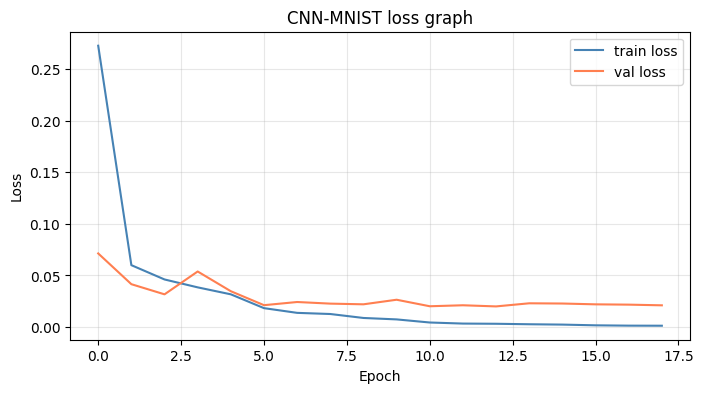

In [72]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

model = CNN().to(device)

criterion     = nn.CrossEntropyLoss()
optimizer     = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

train_losses = []
val_losses   = []
lr_history   = []

best_val_loss = float('inf')
final_acc     = 0
patience      = 5              
no_improve    = 0

for epoch in range(50):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    correct, total = 0, 0
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            batch_val.append(criterion(pred, y_batch).item())
            correct += (torch.argmax(pred, 1) == y_batch).sum().item()
            total   += y_batch.size(0)
    val_loss = np.mean(batch_val)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        final_acc = correct / total * 100
        print(f'Epoch {epoch+1}: train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  acc={correct/total:.4f} lr={current_lr:.6f} improved')
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'input_dim': 28,
            'model_name': 'CNN',
        }
        torch.save(checkpoint, 'CNN.pt')
    else:
        no_improve += 1
        print(f'Epoch {epoch+1}: train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  acc={correct/total:.4f} lr={current_lr:.6f} no improvement ({no_improve}/{patience})')

    if no_improve >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break 

print(f'\nFinal accuracy from CNN: {final_acc:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'steelblue', label='train loss')
plt.plot(val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'CNN-MNIST loss graph')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Kaggle Inference & Submission

Reload the best checkpoint, run it over `test.csv`, and write predictions to `submission.csv`.

In [73]:
test_df = pd.read_csv('test.csv')
X_kaggle = test_df.values
X_kaggle_t = torch.tensor(X_kaggle, dtype=torch.float32)
X_kaggle_t = X_kaggle_t.view(-1, 1, 28, 28)
kaggle_test_loader = DataLoader(X_kaggle_t, batch_size=64, shuffle=False)

checkpoint      = torch.load('CNN.pt', weights_only=False, map_location=device)
final_cnn_model = CNN().to(device)
final_cnn_model.load_state_dict(checkpoint['model_state_dict']) 
final_cnn_model.eval()
kaggle_preds = []

with torch.no_grad():
    for X_batch in kaggle_test_loader:
        X_batch = X_batch.to(device)
        outputs = final_cnn_model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        kaggle_preds.extend(preds.cpu().tolist())


submission = pd.DataFrame({
    'ImageId': range(1, len(kaggle_preds) + 1),
    'Label': kaggle_preds
})

# 6. Save out to CSV
submission.to_csv('submission.csv', index=False)